# NDVI vs Temperature Plot

This notebook plots basin-mean NDVI and air temperature for USGS 11274790 in 2012. Precipitation is excluded, and temperature is shown on the second y-axis in red.

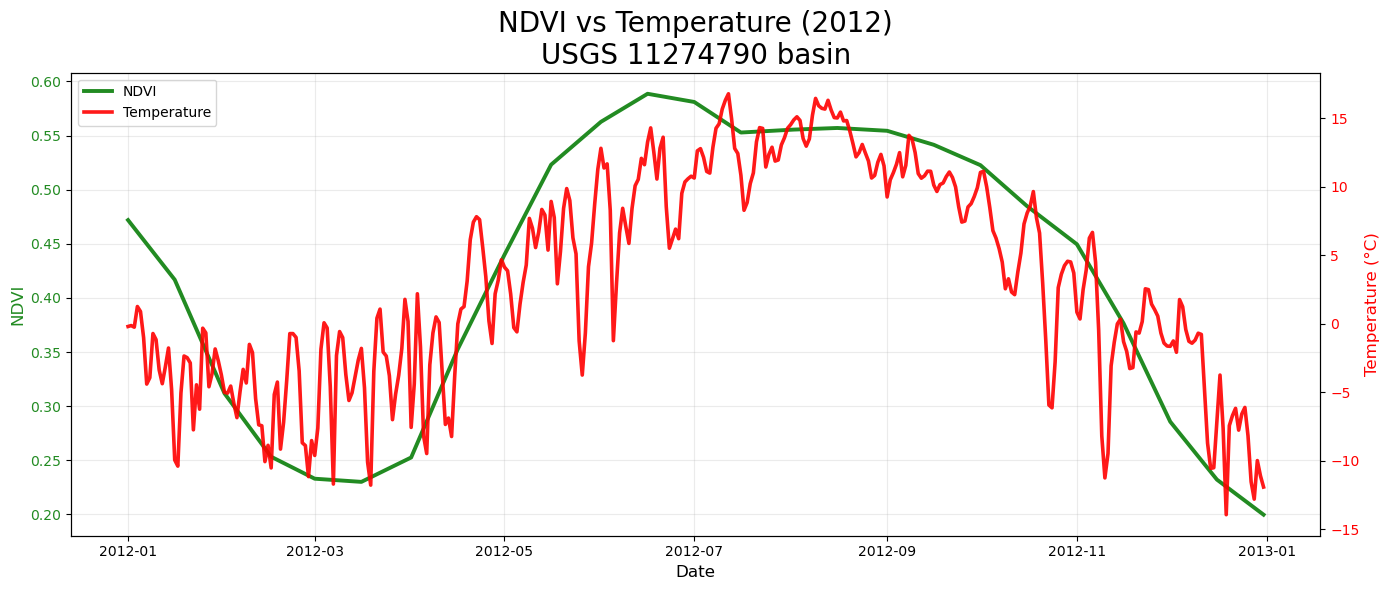

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

gage_id = '11274790'
year = 2012

ndvi_path = f'files/GIMMS/GIMMS_NDVI_daily_{gage_id}.csv'
met_path = f'files/NLDAS/NLDAS_{gage_id}.csv'

ndvi_df = pd.read_csv(ndvi_path, parse_dates=['Date'])[['Date', 'ndvi']]
met_df = pd.read_csv(met_path, parse_dates=['Date'])[['Date', 'temperature']]

plot_df = pd.merge(ndvi_df, met_df, on='Date', how='inner')
plot_df = plot_df[plot_df['Date'].dt.year == year].copy()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Left axis: NDVI
ax1.plot(plot_df['Date'], plot_df['ndvi'], color='forestgreen', linewidth=2.8, label='NDVI')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('NDVI', color='forestgreen', fontsize=12)
ax1.tick_params(axis='y', labelcolor='forestgreen')
ax1.grid(True, alpha=0.25)

# Right axis: Temperature (red)
ax2 = ax1.twinx()
ax2.plot(plot_df['Date'], plot_df['temperature'], color='red', linewidth=2.6, alpha=0.9, label='Temperature')
ax2.set_ylabel('Temperature (°C)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True)

plt.title(f'NDVI vs Temperature ({year})\nUSGS {gage_id} basin', fontsize=20)
fig.tight_layout()
plt.show()